In [1]:
pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 57.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.9 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


# PySpark Pipeline Big Data (data - NYC Taxi 🚕 ) (no Pandas)

The goal is to predict the duration of the trip
Target - trip_duration (The difference between the meter's on and off times)

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml import Pipeline
from pyspark.sql.functions import countDistinct
import math

## 1. Spark Session

In [3]:
# 1. Check Java
import subprocess
try:
    result = subprocess.run(['java', '-version'], 
                          capture_output=True, text=True, timeout=5)
    print("✅ Java found:")
    print(result.stderr[:200])
except:
    print("❌ Java was not found or is not running")

# 2. Check PySpark
try:
    import pyspark
    print(f"✅ PySpark version: {pyspark.__version__}")
except:
    print("❌ PySpark is not installed")

# 3. Ports check
import socket
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
result = sock.connect_ex(('127.0.0.1', 4040))
if result == 0:
    print("⚠️ Port 4040 is busy (Spark UI)")
else:
    print("✅ Port 4040 is free")
sock.close()

# 4. Check memory RAM
import psutil
mem = psutil.virtual_memory()
print(f"💾 Available RAM: {mem.available / 1024**3:.1f} GB")
if mem.available / 1024**3 < 2:
    print("⚠️ Low RAM memory!")

✅ Java found:
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)

✅ PySpark version: 4.0.1
✅ Port 4040 is free
💾 Available RAM: 30.1 GB


In [4]:
# Spark Session
spark = SparkSession.builder \
    .appName('NYC_Taxi_Pure_PySpark') \
    .master('local[*]') \
    .config('spark.driver.memory', '2g') \
    .config('spark.executor.memory', '2g') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.sql.shuffle.partitions', '10') \
    .config('spark.ui.enabled', 'false') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')

print(f'✅ Spark {spark.version} started')
print(f'💻 Mode: Local (cluster emulation)')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 18:35:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark 4.0.1 started
💻 Mode: Local (cluster emulation)


## 2. Data Ingestion (PySpark)

In [5]:
def download_data(year=2024, month=6):
    import requests
    from pathlib import Path
    
    url = f'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet'
    output = Path(f'yellow_tripdata_{year}-{month:02d}.parquet')
    
    print(f'📥 Data load...')
    response = requests.get(url, stream=True)
    with open(output, 'wb') as f:
        for chunk in response.iter_content(8192):
            if chunk: f.write(chunk)
    
    print(f'✅ Downloaded')
    return str(output)

data_file = download_data(2024, 1)

📥 Data load...
✅ Downloaded


### Data dictionary

In [6]:
import requests
import pdfplumber
import pandas as pd
from io import BytesIO

url = 'https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf'
response = requests.get(url)

pdf_file = BytesIO(response.content)

all_tables = []

with pdfplumber.open(pdf_file) as pdf:
    print(f"📄 pages in PDF: {len(pdf.pages)}\n")
    
    for page_num, page in enumerate(pdf.pages, 1):
        tables = page.extract_tables()
        if tables:            
            for table_num, table in enumerate(tables, 1):
                if table and len(table) > 1:  
                    df = pd.DataFrame(table[1:], columns=table[0])
                    all_tables.append({
                        'page': page_num,
                        'table_num': table_num,
                        'data': df
                    })
                    
print(f" All tables extracted : {len(all_tables)}\n")

'''
for i, table_info in enumerate(all_tables):
    print(f"\n{'='*60}")
    print(f" Table {i+1} (Page {table_info['page']}, Table {table_info['table_num']})")
    print(f"{'='*60}")
    display(table_info['data'])
    print()
'''
table_info = all_tables[0]
table_info['data'].columns = ['name','f0','f1','description']
table_info['data'] = table_info['data'][['name','description']]
for i in range(1,len(table_info['data'])):
    print('\033[1m'+table_info['data']['name'].iloc[i]+'\033[0m' , ' - ', table_info['data']['description'].iloc[i])
    print()

📄 pages in PDF: 1

 All tables extracted : 1

VendorID  -  A code indicating the TPEP provider that provided the record.
1 = Creative Mobile Technologies, LLC
2 = Curb Mobility, LLC
6 = Myle Technologies Inc
7 = Helix

tpep_pickup_datetime  -  The date and time when the meter was engaged.

tpep_dropoff_datetime  -  The date and time when the meter was disengaged.

passenger_count  -  The number of passengers in the vehicle.

trip_distance  -  The elapsed trip distance in miles reported by the taximeter.

RatecodeID  -  The final rate code in effect at the end of the trip.
1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride
99 = Null/unknown

store_and_fwd_flag  -  This flag indicates whether the trip record was held in vehicle memory before
sending to the vendor, aka “store and forward,” because the vehicle did not
have a connection to the server.
Y = store and forward trip
N = not a store and forward trip

PULocationID  -  TLC Taxi Zone in

In [7]:
# Read parquet PySpark
df_raw = spark.read.parquet(data_file)
print(f'All count rows = {df_raw.count():,}')

# Sample for demo
SAMPLE_FRACTION = 0.02  # 2% for fast demo
df_raw = df_raw.sample(fraction=SAMPLE_FRACTION, seed=42)

print(f'For model take random {SAMPLE_FRACTION:.0%} rows = {df_raw.count():,} ')

All count rows = 2,964,624
For model take random 2% rows = 59,661 


In [8]:
### Data Schema
df_raw.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



## 3.ETL Pipeline

In [9]:
# Create target 
df = df_raw.withColumn(
    'trip_duration',
    unix_timestamp('tpep_dropoff_datetime') - unix_timestamp('tpep_pickup_datetime')
)

# Data quality filters

# trip_duration should be greater then 1 minute and less then 2 hours
# trip_distance should be greater then 0.1 mile and less then 100 mile 
df = df.filter(
    (col('trip_duration').between(60, 7200)) &
    (col('trip_distance').between(0.1, 100)) &
    (col('fare_amount').between(2.5, 500)) &
    (col('passenger_count').between(1, 6))
)

# avg_speed for filtering only (not as feature!)
df = df.withColumn(
    'avg_speed_temp',
    when(col('trip_duration') > 0, 
         col('trip_distance') / (col('trip_duration') / 3600)).otherwise(0)
).filter(
    col('avg_speed_temp').between(0, 100)
).drop('avg_speed_temp')  # ! Don't use as feature (has trip_duration)

print(f'✅ Clean data: {df.count():,} trips')

✅ Clean data: 54,451 trips


## 4. Feature Engineering (PySpark)

In [10]:
# Create Target - trip_duration

df = df_raw.withColumn(
    'trip_duration',
    unix_timestamp('tpep_dropoff_datetime') - unix_timestamp('tpep_pickup_datetime')
)

In [11]:
# passenger_count, trip_distance already exist
# just ensure correct type

df = df.withColumn(
    "passenger_count",
    col("passenger_count").cast("int")
)

df = df.withColumn(
    "trip_distance",
    col("trip_distance").cast("double")
)

In [12]:
# TIME FEATURES

df = ( 
    df
    .withColumn(
        "pickup_hour",
        hour("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_dayofweek",
        dayofweek("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_day",
        dayofmonth("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_week",
        weekofyear("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_month",
        month("tpep_pickup_datetime")
    )
    .withColumn(
        "pickup_quarter",
        quarter("tpep_pickup_datetime")
    )
)

In [13]:
# WEEKEND FLAG

df = df.withColumn(
    "is_weekend",
    when(col("pickup_dayofweek").isin([1,7]), 1).otherwise(0)
)


In [14]:
# RUSH HOURS

df = (
    df
    .withColumn(
        "is_morning_rush",
        when(col("pickup_hour").between(7,10), 1).otherwise(0)
    )
    .withColumn(
        "is_evening_rush",
        when(col("pickup_hour").between(16,20), 1).otherwise(0)
    )
    .withColumn(
        "is_rush_hour",
        greatest(
            col("is_morning_rush"),
            col("is_evening_rush")
        )
    )
)

In [15]:
# CYCLICAL FEATURES
# prevents discontinuity (23 → 0 hour problem)


df = (
    df
    .withColumn(
        "hour_sin",
        sin(2 * math.pi * col("pickup_hour") / 24)
    )
    .withColumn(
        "hour_cos",
        cos(2 * math.pi * col("pickup_hour") / 24)
    )
    .withColumn(
        "dow_sin",
        sin(2 * math.pi * col("pickup_dayofweek") / 7)
    )
    .withColumn(
        "dow_cos",
        cos(2 * math.pi * col("pickup_dayofweek") / 7)
    )
    .withColumn(
        "month_sin",
        sin(2 * math.pi * col("pickup_month") / 12)
    )
    .withColumn(
        "month_cos",
        cos(2 * math.pi * col("pickup_month") / 12)
    )
)

In [16]:
# INTERACTION FEATURES

df = df.withColumn(
    "distance_hour_interaction",
    col("trip_distance") * col("pickup_hour")
)

df = df.withColumn(
    "distance_rush_interaction",
    col("trip_distance") * col("is_rush_hour")
)

In [17]:
# CACHE 

df = df.cache()

## 5. Preprocessing (PySpark)

In [18]:
# Data filter

# trip_duration should be greater then 1 minute and less then 2 hours
# trip_distance should be greater then 0.1 mile and less then 100 mile 

df = df.filter(
   (col('trip_duration').between(60, 7200)) & 
    (col('trip_distance').between(0.1, 100)) &
    (col('passenger_count').between(1, 6))
)

These values ​​directly depend on the duration and route of the trip:

fare_amount
→ calculated based on time and distance

total_amount
→ includes fare + tolls + surcharge

tip_amount
→ known only after payment

tolls_amount
→ depends on the selected route

congestion_surcharge
→ depends on the travel zone (often dropoff)

extra
→ night/rush surcharge (partially known, but actually calculated after)

airport_fee
→ determined by the airport trip

improvement_surcharge

payment_type

In [19]:
NUMERIC_FEATURES = [

    "passenger_count",
    "trip_distance",

    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_week",
    "pickup_month",
    "pickup_quarter",

    "hour_sin",
    "hour_cos",

    "dow_sin",
    "dow_cos",

    "month_sin",
    "month_cos",

    "is_weekend",
    "is_morning_rush",
    "is_evening_rush",
    "is_rush_hour",

    "distance_hour_interaction",
    "distance_rush_interaction"

]

df.select(NUMERIC_FEATURES+["trip_duration"]).describe().show()

quantiles = {}

for c in NUMERIC_FEATURES+["trip_duration"]:
    quantiles[c] = df.approxQuantile(
        c,
        [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99],
        0.01
    )

for k, v in quantiles.items():
    print(k, v)

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------+--------------+-------------------+-------------------+--------------------+--------------------+-------------------+--------------------+------------------+-------------------+-------------------+------------------+-------------------------+-------------------------+-----------------+
|summary|   passenger_count|     trip_distance|      pickup_hour|  pickup_dayofweek|        pickup_day|       pickup_week|pickup_month|pickup_quarter|           hour_sin|           hour_cos|             dow_sin|             dow_cos|          month_sin|           month_cos|        is_weekend|    is_morning_rush|    is_evening_rush|      is_rush_hour|distance_hour_interaction|distance_rush_interaction|    trip_duration|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------+--------------+------

In [20]:
CATEGORICAL_FEATURES = [
     "VendorID",
   "PULocationID",
  "DOLocationID",
   "RatecodeID"
]

df.select(
    countDistinct("VendorID"),
    countDistinct("PULocationID"),
    countDistinct("DOLocationID"),
    countDistinct("RatecodeID")
).show()

+------------------------+----------------------------+----------------------------+--------------------------+
|count(DISTINCT VendorID)|count(DISTINCT PULocationID)|count(DISTINCT DOLocationID)|count(DISTINCT RatecodeID)|
+------------------------+----------------------------+----------------------------+--------------------------+
|                       2|                         203|                         245|                         6|
+------------------------+----------------------------+----------------------------+--------------------------+



In [21]:
def show_distribution(df, columns):
    for c in columns:
        print(f"\n=== {c} ===")
        df.groupBy(c).count().orderBy(col("count").desc()).show(10, False)

show_distribution(df, CATEGORICAL_FEATURES)


=== VendorID ===
+--------+-----+
|VendorID|count|
+--------+-----+
|2       |42241|
|1       |12779|
+--------+-----+


=== PULocationID ===
+------------+-----+
|PULocationID|count|
+------------+-----+
|237         |2795 |
|132         |2759 |
|161         |2749 |
|236         |2626 |
|162         |2032 |
|186         |2028 |
|230         |1991 |
|142         |1941 |
|138         |1795 |
|163         |1641 |
+------------+-----+
only showing top 10 rows

=== DOLocationID ===
+------------+-----+
|DOLocationID|count|
+------------+-----+
|236         |2674 |
|237         |2476 |
|161         |2162 |
|230         |1734 |
|239         |1657 |
|142         |1632 |
|162         |1603 |
|170         |1592 |
|141         |1584 |
|68          |1408 |
+------------+-----+
only showing top 10 rows

=== RatecodeID ===
+----------+-----+
|RatecodeID|count|
+----------+-----+
|1         |52226|
|2         |1862 |
|99        |535  |
|3         |156  |
|5         |124  |
|4         |117  |
+-----

## 6. Train/Test Split (PySpark)

In [22]:
# Filter only existing ones
numeric_features = [f for f in NUMERIC_FEATURES if f in df.columns]
categorical_features = [f for f in CATEGORICAL_FEATURES if f in df.columns]

In [23]:
# Data preparing
df_ml = df.select(['trip_duration'] + numeric_features + categorical_features).na.drop()

print(f'✅ Ready for ML: {df_ml.count():,} записей')

# Train/Test split (80/20) - PySpark
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

train_df = train_df.cache()
test_df = test_df.cache()

print(f'\n📊 Train: {train_df.count():,}')
print(f'📊 Test: {test_df.count():,}')

✅ Ready for ML: 55,020 записей



📊 Train: 44,195
📊 Test: 10,825


## 7. ML Pipeline (PySpark MLlib)

In [24]:
# Building a Pipeline (production pattern)
stages = []

# 1. StringIndexer for categorical features
indexed_features = []
for cat_col in categorical_features:
    indexer = StringIndexer(
        inputCol=cat_col,
        outputCol=f'{cat_col}_indexed',
        handleInvalid='keep'
    )
    stages.append(indexer)
    indexed_features.append(f'{cat_col}_indexed')

# 2. VectorAssembler - assemble all features into a vector
all_features = numeric_features + indexed_features

assembler = VectorAssembler(
    inputCols=all_features,
    outputCol='features',
    handleInvalid='skip'
)
stages.append(assembler)

#3. Gradient Boosted Trees (PySpark MLlib)
gbt = GBTRegressor(
    featuresCol='features',
    labelCol='trip_duration',
    maxBins=300, 
    maxDepth=5,
    maxIter=80,
    seed=42
)
stages.append(gbt)

# Building a Pipeline
pipeline = Pipeline(stages=stages)

print(f'✅ Pipeline created: {len(stages)} stages')
print(f'📊 Features for model: {len(all_features)}')

✅ Pipeline created: 6 stages
📊 Features for model: 24


## 8. Grid Search for Hyperparameter Selection (PySpark)

**Use TrainValidationSplit** 

In [25]:
# ParamGrid for Gradient Boosted Trees
paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [5, 8, 10]) \
    .addGrid(gbt.maxIter, [20, 50, 100]) \
    .addGrid(gbt.stepSize, [0.05, 0.1]) \
    .build()

print('🔍 Grid Search parameters:')
print(f'   maxDepth: [5, 8, 10]')
print(f'   maxIter: [20, 50, 100]')
print(f'   stepSize: [0.05, 0.1]')
print(f'\n📊 Total combinations: {len(paramGrid)} (3×3×2)')

🔍 Grid Search parameters:
   maxDepth: [5, 8, 10]
   maxIter: [20, 50, 100]
   stepSize: [0.05, 0.1]

📊 Total combinations: 18 (3×3×2)


In [26]:
# Evaluator (metric for evaluation)
evaluator = RegressionEvaluator(
    labelCol='trip_duration',
    predictionCol='prediction',
    metricName='rmse'
)

# TrainValidationSplit
# Splits the train into 80% training and 20% validation
tvs = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.8,  # 80% for training, 20% for validation
    seed=42,
    parallelism=4
)

print('✅ TrainValidationSplit is configured')
print(f'📊 Train/Validation split: 80/20')
print(f'📊 Metric: RMSE')
print(f'\n🚀{len(paramGrid)} models will be trained')

✅ TrainValidationSplit is configured
📊 Train/Validation split: 80/20
📊 Metric: RMSE

🚀18 models will be trained


In [27]:
import time
start = time.time()

tvs_model = tvs.fit(train_df)

elapsed = time.time() - start

print(f'\n✅ Grid Search completed in {elapsed:.1f} seconds')


✅ Grid Search completed in 4189.0 seconds


In [28]:
# Best parameters
best_model = tvs_model.bestModel
gbt_model = best_model.stages[-1]  # Last stage = GBT model

print('🏆 Best hyperparameters:')
print(f'   maxDepth: {gbt_model.getMaxDepth()}')
print(f'   maxIter: {gbt_model.getMaxIter()}')
print(f'   stepSize: {gbt_model.getStepSize()}')

🏆 Best hyperparameters:
   maxDepth: 5
   maxIter: 20
   stepSize: 0.05


## 9. Evaluation на Test Set (PySpark)

In [29]:
# Predictions  (in PySpark)
predictions_train = tvs_model.transform(train_df)
predictions_test = tvs_model.transform(test_df)

# Metrics (in PySpark)
rmse_eval = RegressionEvaluator(
    labelCol='trip_duration',
    predictionCol='prediction',
    metricName='rmse'
)

mae_eval = RegressionEvaluator(
    labelCol='trip_duration',
    predictionCol='prediction',
    metricName='mae'
)

r2_eval = RegressionEvaluator(
    labelCol='trip_duration',
    predictionCol='prediction',
    metricName='r2'
)

rmse_train = rmse_eval.evaluate(predictions_train)
mae_train = mae_eval.evaluate(predictions_train)
r2_train = r2_eval.evaluate(predictions_train)

print('='*60)
print('🎯 RESULTS ON THE TRAIN')
print('='*60)
print(f'RMSE: {rmse_train: .2f} seconds ({rmse_train/60: .2f} minutes)')
print(f'MAE: {mae_train: .2f} seconds ({mae_train/60: .2f} minutes)')
print(f'R²: {r2_train: .4f} ({r2_train*100: .2f}%)')
print('='*60)
print(f'\n💡 The model explains {r2_train*100: .1f}% of the variation')
print()

rmse_test = rmse_eval.evaluate(predictions_test)
mae_test = mae_eval.evaluate(predictions_test)
r2_test = r2_eval.evaluate(predictions_test)

print('='*60)
print('🎯 RESULTS ON THE TEST')
print('='*60)
print(f'RMSE: {rmse_test: .2f} seconds ({rmse_test/60: .2f} minutes)')
print(f'MAE: {mae_test: .2f} seconds ({mae_test/60: .2f} minutes)')
print(f'R²: {r2_test: .4f} ({r2_test*100: .2f}%)')
print('='*60)
print(f'\n💡 The model explains {r2_test*100: .1f}% of the variation')
print(f'💡 Everything calculated in PySpark (no Pandas)')

🎯 RESULTS ON THE TRAIN
RMSE:  283.15 seconds ( 4.72 minutes)
MAE:  186.37 seconds ( 3.11 minutes)
R²:  0.8365 ( 83.65%)

💡 The model explains  83.6% of the variation

🎯 RESULTS ON THE TEST
RMSE:  387.83 seconds ( 6.46 minutes)
MAE:  219.21 seconds ( 3.65 minutes)
R²:  0.6948 ( 69.48%)

💡 The model explains  69.5% of the variation
💡 Everything calculated in PySpark (no Pandas)


Model generalization analysis

R²

* Train: 0.836
* Test: 0.695
The performance drops by 14 percentage points, indicating clear overfitting rather than random noise.

Interpretation

The Gradient Boosted Trees model likely:

* learned specific patterns from the training set

* partially memorized noise

* generalizes worse on unseen data, especially on rare and long trips

Possible causes

* model complexity is too high (deep trees)

* too many boosting iterations

* limited training data (only ~2% sample)

* presence of redundant or highly correlated features

Conclusion  

The model demonstrates strong fit on the training data, but its generalization ability is weaker, suggesting the need for regularization, simpler model configuration, or more training data.

In [30]:
# Feature Importance (from GBT model)
feature_importance = gbt_model.featureImportances

importance_list = []
for idx, importance in enumerate(feature_importance):
    if idx < len(all_features):
        importance_list.append((all_features[idx], float(importance)))

importance_list.sort(key=lambda x: x[1], reverse=True)

print('\n📊 Top 10 most important features:\n')
for i, (feat, imp) in enumerate(importance_list[:10], 1):
    print(f'{i:2d}. {feat:25s} {imp:.4f}')


📊 Top 10 most important features:

 1. trip_distance             0.3773
 2. DOLocationID_indexed      0.2408
 3. PULocationID_indexed      0.1540
 4. hour_cos                  0.0505
 5. pickup_hour               0.0371
 6. dow_cos                   0.0262
 7. distance_hour_interaction 0.0241
 8. pickup_dayofweek          0.0200
 9. pickup_day                0.0189
10. dow_sin                   0.0106


## 10. Saving the model (PySpark)

In [31]:
# Save the best model (PySpark Pipeline)
model_path = 'nyc_taxi_pyspark_model'

tvs_model.bestModel.write().overwrite().save(model_path)

print(f'✅ Model saved: {model_path}')
print(f'\n💡 Model includes:')
print(f' - StringIndexer for categories')
print(f' - VectorAssembler for features')
print(f' - GBT model with the best parameters')
print(f'\n💡 Loading:')
print(f' from pyspark.ml import PipelineModel')
print(f' model = PipelineModel.load("{model_path}")')

✅ Model saved: nyc_taxi_pyspark_model

💡 Model includes:
 - StringIndexer for categories
 - VectorAssembler for features
 - GBT model with the best parameters

💡 Loading:
 from pyspark.ml import PipelineModel
 model = PipelineModel.load("nyc_taxi_pyspark_model")


## 11. Visualization (minimal conversion for charts only)

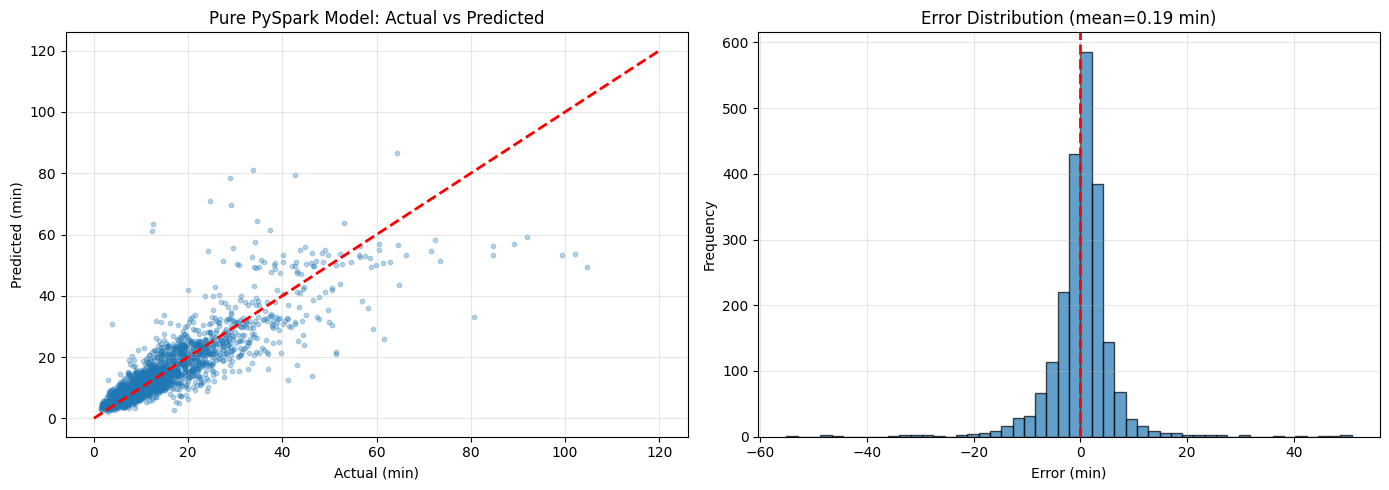

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take a small sample for visualization
viz_sample = predictions_test.select( 
'trip_duration', 'prediction'
).sample(fraction=0.2, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Actual vs Predicted
axes[0].scatter( 
viz_sample['trip_duration']/60, 
viz_sample['prediction']/60, 
alpha=0.3, s=10
)
axes[0].plot([0, 120], [0, 120], 'r--', lw=2)
axes[0].set_xlabel('Actual (min)')
axes[0].set_ylabel('Predicted (min)')
axes[0].set_title('Pure PySpark Model: Actual vs Predicted')
axes[0].grid(alpha=0.3)

# Error distribution
errors = (viz_sample['prediction'] - viz_sample['trip_duration']) / 60
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Error (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution (mean={errors.mean():.2f} min)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
from pyspark.sql.functions import avg, abs, sqrt, col
from pyspark.sql.functions import mean as _mean
from pyspark.sql.functions import pow

# errors
pred = col("prediction")
actual = col("trip_duration")

df_eval = predictions_test.withColumn("error", pred - actual)

metrics = df_eval.select(
    _mean("error").alias("ME"),  # Mean Error (bias)
    _mean(abs(col("error"))).alias("MAE"),
    sqrt(_mean(pow(col("error"), 2))).alias("RMSE")
)

metrics.show()

+-----------------+------------------+-----------------+
|               ME|               MAE|             RMSE|
+-----------------+------------------+-----------------+
|14.11784509788958|219.21259877484013|387.8258733249622|
+-----------------+------------------+-----------------+



In [34]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="trip_duration",
    predictionCol="prediction",
    metricName="r2"
)

print("R2:", evaluator.evaluate(predictions_test))

R2: 0.6948271034759986


Test set performance summary

* R²: 0.695 → the model explains ≈69.5% of the variation in trip duration.  

* MAE: 219 sec (≈3.65 min) — mean absolute forecast error.

* RMSE: 388 sec (≈6.46 min) — errors increase on infrequent and long trips.

* ME: +14 sec — bias is almost absent; the model, on average, neither systematically overestimates nor underestimates trip duration.


In [35]:
df_bins = df_eval.withColumn(
    "duration_bin",
    (col("trip_duration") / 600).cast("int")  # бины по 10 минут
)

df_bins.groupBy("duration_bin").agg(
    _mean(abs(col("error"))).alias("MAE_bin")
).orderBy("duration_bin").show()

+------------+------------------+
|duration_bin|           MAE_bin|
+------------+------------------+
|           0|118.07232863305177|
|           1|189.77284880084673|
|           2|318.69319440726457|
|           3|506.99880803990726|
|           4| 630.9600528271487|
|           5| 492.9563545369024|
|           6|  988.195253727418|
|           7| 1312.940546832273|
|           8|1781.5308262360227|
|           9|3174.5084055626735|
|          10|3474.2286182155717|
|          11|3114.5526641895326|
+------------+------------------+



The error increases monotonically with trip duration:  

* Short trips → MAE ≈ 118–190 sec

* Medium trips → MAE ≈ 300–630 sec

* Long trips → MAE reaches 3000+ sec

Interpretation:  
The model predicts short and typical trips well, but sharply loses accuracy on long trips. This is a characteristic sign of heteroscedasticity and the rarity of long trips in the data.

In [36]:
df_eval.groupBy("pickup_hour").agg(
    _mean("error").alias("mean_error_by_hour")
).orderBy("pickup_hour").show()

+-----------+-------------------+
|pickup_hour| mean_error_by_hour|
+-----------+-------------------+
|          0| 10.969318259043437|
|          1|  32.54591161221678|
|          2|  64.49575108957136|
|          3|  147.3709420842047|
|          4|  217.7258509892609|
|          5| 210.50056035389903|
|          6| 132.52336076864512|
|          7| 106.93876914862912|
|          8| 29.865385388469395|
|          9|  32.33248405336804|
|         10| 38.311119293890044|
|         11|  8.528437961183949|
|         12| 14.613877663270555|
|         13|  30.18597093383632|
|         14|-29.183388284501937|
|         15| -42.63372455590217|
|         16|-27.420922602302863|
|         17| -7.256915985777103|
|         18|-0.5210993372454384|
|         19|-21.321709061090413|
+-----------+-------------------+
only showing top 20 rows


The error systematically depends on the time of day:

* Night/early morning (3–6) → the model significantly underestimates the duration (error up to +217 sec)

* Day (10–13) → the error is minimal, the predictions are most stable

* After 2:00 PM → the model begins to overestimate the duration (negative error)

Interpretation:  
The model does not fully capture the daily traffic dynamics, especially in the morning hours with high trip variability.

In [37]:
df_eval.select(
    (col("prediction") / col("trip_duration")).alias("ratio")
).summary().show()

+-------+-------------------+
|summary|              ratio|
+-------+-------------------+
|  count|              10825|
|   mean|  1.114330153371521|
| stddev| 0.4739319669408305|
|    min|0.15069442964012364|
|    25%| 0.8583600682190349|
|    50%| 1.0501258445744062|
|    75%|  1.275715884099174|
|    max| 21.578130859286524|
+-------+-------------------+



The prediction / true distribution shows that the model slightly overestimates trip duration on average.

* Mean = 1.11 → the average prediction is ~11% higher than the actual value.

* Median = 1.05 → typical error is about +5%

* 75% of trips have a ratio ≤ 1.28 → the error typically does not exceed ~28%.

* Max = 21.6 → there are strong outliers where the model significantly overestimates trip duration (usually rare or anomalous trips).

Result:  
The model is moderately accurate overall, but has right-sided outliers and a tendency toward slight overprediction.

In [38]:
spark.stop()
print('✅ Spark has stopped')

✅ Spark has stopped


## 📊 Summary

### ✅ What we've done:

1. **100% PySpark Pipeline**
- ETL in PySpark
- Feature Engineering in PySpark
- ML in PySpark MLlib
- Grid Search in PySpark

2. **Train/Test Split**
- 80% train, 20% test
- Everything in PySpark DataFrame

3. **Grid Search (TrainValidationSplit)**
- 18 parameter combinations
- Automatic selection of the best
- Without cross-validation (faster)

4. **Gradient Boosted Trees**
- PySpark MLlib (not CatBoost)
- Production-ready
- Scalable to clusters

5. **Evaluation**
- RMSE, MAE, R² in PySpark
- Feature importance
- Model saving

### 💡 Why without Pandas:

**Advantages:**
- ✅ Scalability for big data
- ✅ Distributed computing
- ✅ Ready for Spark clusters
- ✅ Production-ready code

**Disadvantages:**
- ⚠️ Fewer algorithms (no CatBoost)
- ⚠️ GBT instead of CatBoost

